In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('../FeatureEngineering/gurgaon_properties_cleaned_v2.csv')

In [10]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   str    
 1   society              3802 non-null   str    
 2   sector               3803 non-null   str    
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   str    
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   str    
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   str    
 12  super_built_up_area  1915 non-null   float64
 13  built_up_area        1187 non-null   float64
 14  carpet_area          1944 non-null   float64
 15  study room           3803 non-null   int64  
 16 

In [12]:
df.duplicated().sum()

np.int64(122)

In [13]:
df.drop_duplicates(keep='first', inplace=True)

In [14]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25


In [15]:
# eda

1. property_type

<Axes: xlabel='property_type'>

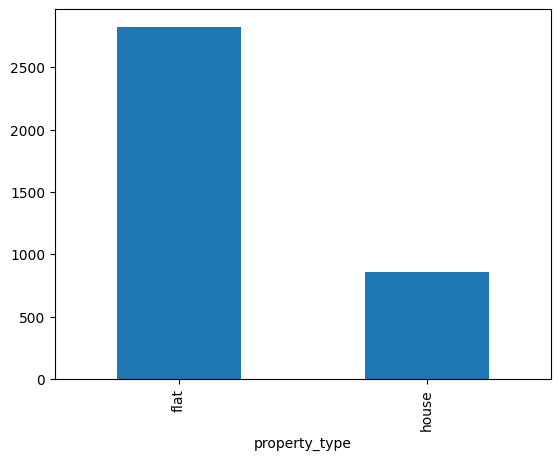

In [16]:
df['property_type'].value_counts().plot(kind='bar')

In [17]:
df['property_type'].isnull().sum()

np.int64(0)

1. flats are in majority (~75%) houses (~25%)
2. no missing value

2. society

In [28]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     44
dlf new town heights                     42
                                       ... 
ansal sushant lok 2                       1
saksham welfare association               1
sector 57 huda                            1
huda                                      1
huda floor                                1
Name: count, Length: 675, dtype: int64

property_type
flat     0.883255
house    0.116745
Name: count, dtype: float64

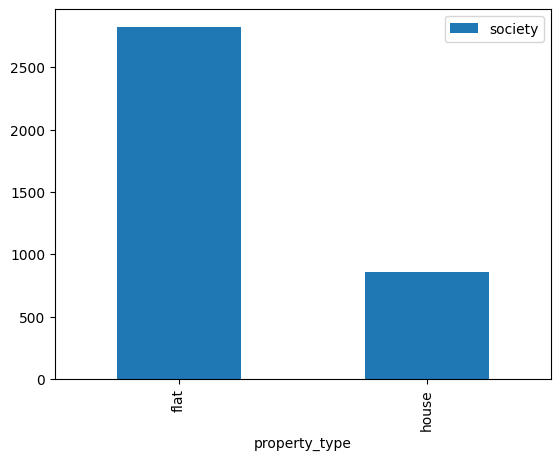

In [ ]:
df[['society','property_type']].groupby('property_type').count().plot(kind='bar')


In [35]:
# percentage of flat and houses under society
df[df['society']!='independent']['property_type'].value_counts()/df[df['society']!='independent'].shape[0]

property_type
flat     0.883255
house    0.116745
Name: count, dtype: float64

<Axes: xlabel='society'>

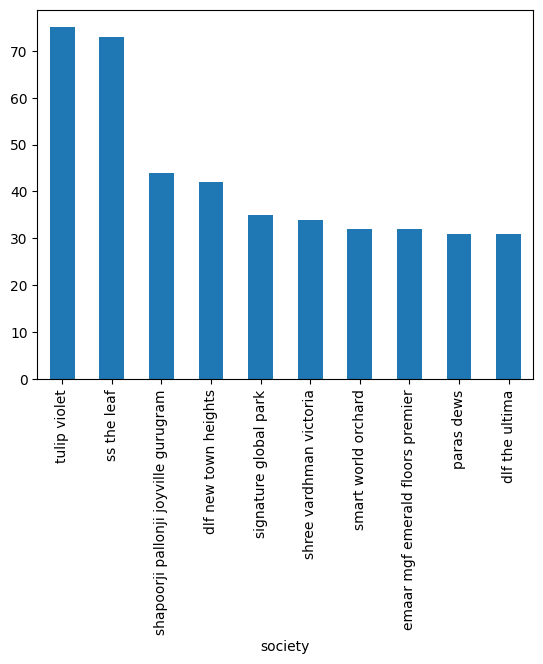

In [ ]:
#top 10 societies
df[df['society']!='independent']['society'].value_counts().head(10).plot(kind='bar')

In [32]:
df[df['society']=='independent'].shape[0]/df.shape[0]

0.13202933985330073

In [36]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023482
ss the leaf                             0.046337
shapoorji pallonji joyville gurugram    0.060113
dlf new town heights                    0.073262
signature global park                   0.084220
                                          ...   
the close north                         0.490607
puri emerald bay                        0.494678
ats kocoon                              0.498748
central park flower valley              0.502505
mvn athens                              0.506262
Name: proportion, Length: 75, dtype: float64

In [37]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(275),
 'Very Low (1)': np.int64(305)}

1. 13% houses are independent not under any society
2. 1 null value
3. total 674 societies
4. under the society 88.3% are flats and 11.3% are houses
5. The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
6. 'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(275),
 'Very Low (1)': np.int64(305)


3. sector

In [42]:
df['sector'].value_counts()

sector
sohna road    154
sector 37     115
sector 102    110
sector 85     108
sector 70     104
             ... 
sector 30       5
sector 80       5
sector 88       3
sector 73       3
sector 27       3
Name: count, Length: 102, dtype: int64

In [47]:
df['sector'].value_counts(normalize=True).cumsum().head(22)

sector
sohna road    0.041836
sector 37     0.073078
sector 102    0.102961
sector 85     0.132301
sector 70     0.160554
sector 92     0.187721
sector 69     0.212986
sector 90     0.237164
sector 81     0.260799
sector 65     0.284434
sector 109    0.307797
sector 79     0.328172
sector 104    0.346917
sector 33     0.365662
sector 67     0.384135
sector 83     0.402608
sector 43     0.420538
sector 86     0.437924
sector 50     0.455311
sector 95     0.472154
sector 2      0.488998
sector 82     0.505297
Name: proportion, dtype: float64

<Axes: xlabel='sector'>

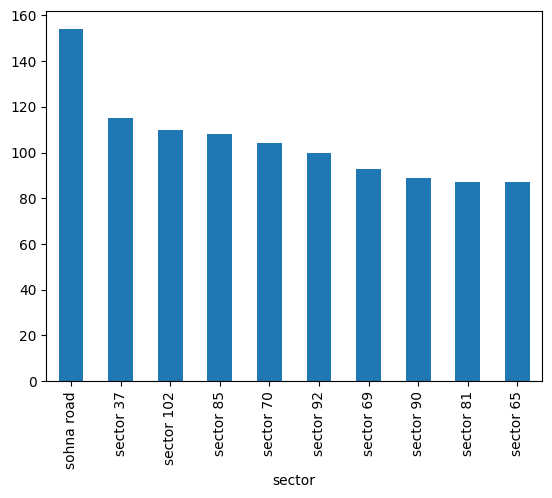

In [48]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [49]:
society_counts = df['sector'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(5),
 'High (50-100)': np.int64(23),
 'Average (10-49)': np.int64(56),
 'Low (2-9)': np.int64(18),
 'Very Low (1)': np.int64(0)}

In [50]:
df['sector'].isnull().sum()

np.int64(0)

1. no null values
2. {'Very High (>100)': np.int64(5),
 'High (50-100)': np.int64(23),
 'Average (10-49)': np.int64(56),
 'Low (2-9)': np.int64(18),
 'Very Low (1)': np.int64(0)}
3. 21 sector's have 50% of properties
4. 102 total sector count

4. price

In [51]:
df['price'].isnull().sum()

np.int64(17)

In [52]:
df['price'].describe()

count    3664.000000
mean        2.532876
std         2.979438
min         0.075000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: >

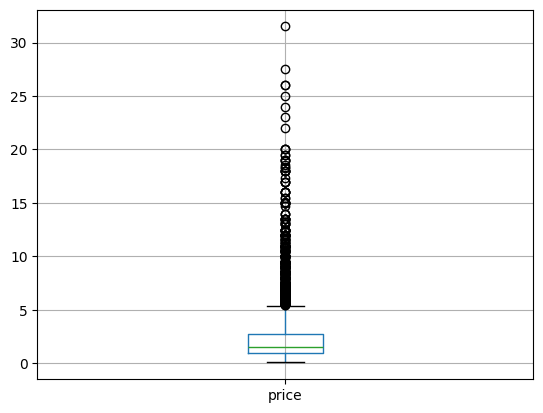

In [55]:
df.boxplot(column='price')

<Axes: xlabel='price', ylabel='Count'>

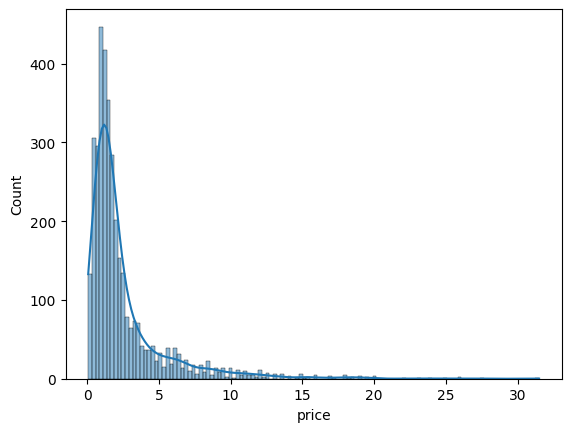

In [59]:
sns.histplot(df['price'], kde=True)

Descriptive Statistics:

Count: There are 3,664 non-missing price entries.
Mean Price: The average price is approximately 2.53 crores.
Median Price: The median (or 50th percentile) price is 1.52 crores.
Standard Deviation: The prices have a standard deviation of 2.97, indicating variability in the prices.
Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
Visualizations:

Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
Missing Values: There are 17 missing values in the price column.

In [60]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.28023675776131 14.945852922080501


Skewness: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

Kurtosis: The kurtosis value is approximately 14.94. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [61]:
quantiles=df['price'].quantile([0.01,0.05,0.95,0.99])
quantiles

0.01     0.25000
0.05     0.37015
0.95     8.50000
0.99    15.24800
Name: price, dtype: float64

Quantile Analysis:

1% Quantile: Only 1% of properties are priced below 0.25 crores.
5% Quantile: 5% of properties are priced below 0.37 crores.
95% Quantile: 95% of properties are priced below 8.5 crores.
99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [63]:
q1=df['price'].describe()['25%']
q3=df['price'].describe()['75%']
iqr=q3-q1

In [65]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [70]:
outliers=df[(df['price']<-1.75) | (df['price'] > 5.45)]
outliers.shape

(425, 24)

In [73]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

Based on the IQR method, there are 425 properties considered as outliers.
These outliers have an average price of approximately 9.24 crores.
The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

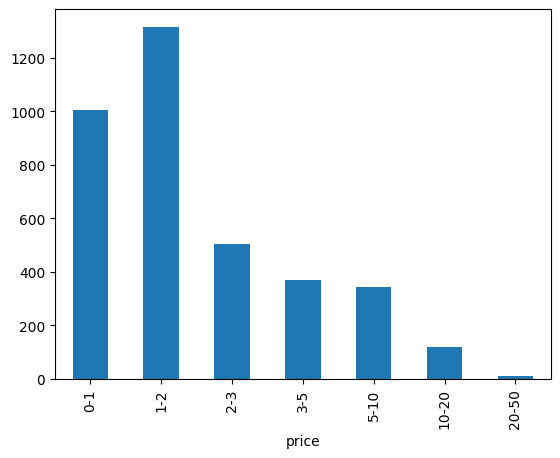

In [74]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
There's a significant drop in the number of properties priced above "5 crores."

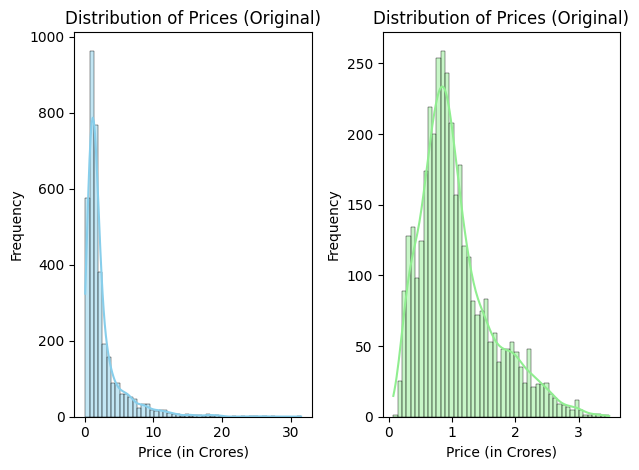

In [77]:
# log transformation

# normal
plt.subplot(1,2,1)
sns.histplot(df['price'],kde=True,bins=50,color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# with transformation
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']),kde=True,bins=50,color='lightgreen')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [78]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0745760542760259 0.9656665453678812


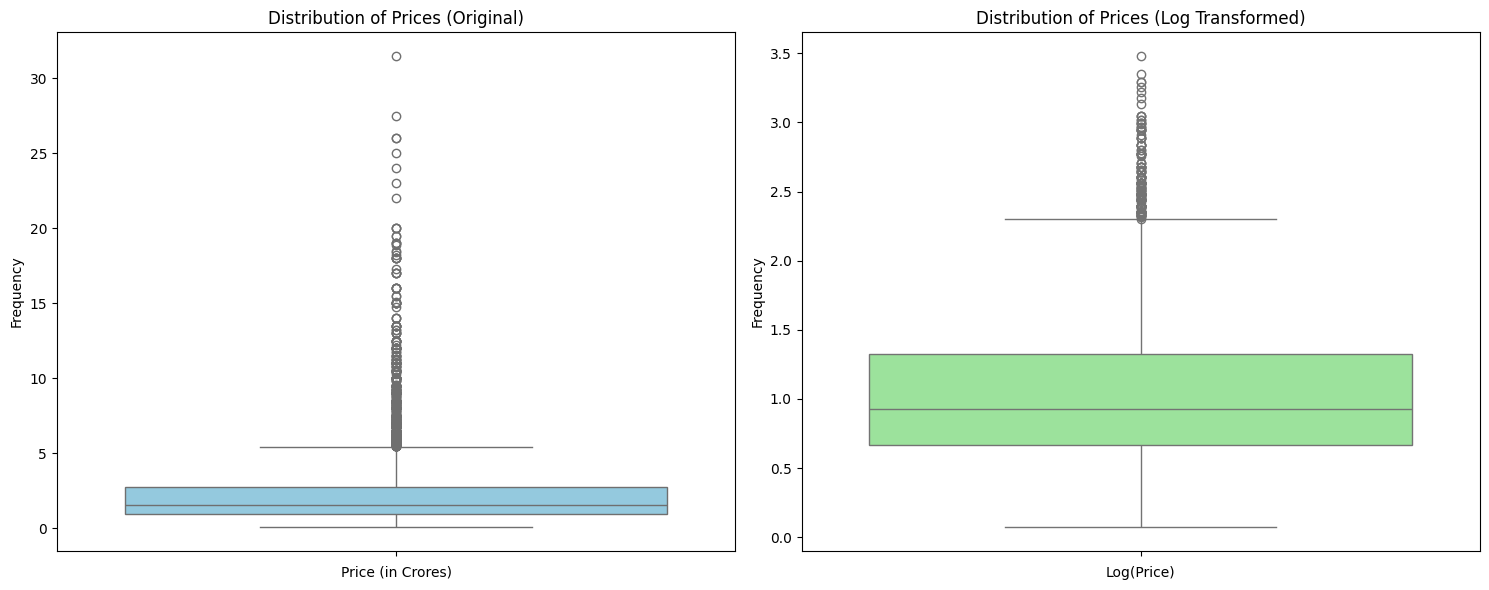

In [79]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

log transformation keep outlier treatment and skew,kutosis good

5. price_per_sqft

In [80]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.0


In [81]:
df['price_per_sqft'].describe()

count      3664.000000
mean      13891.845251
std       23197.759610
min           4.000000
25%        6818.000000
50%        9022.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

In [82]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

<Axes: ylabel='price_per_sqft'>

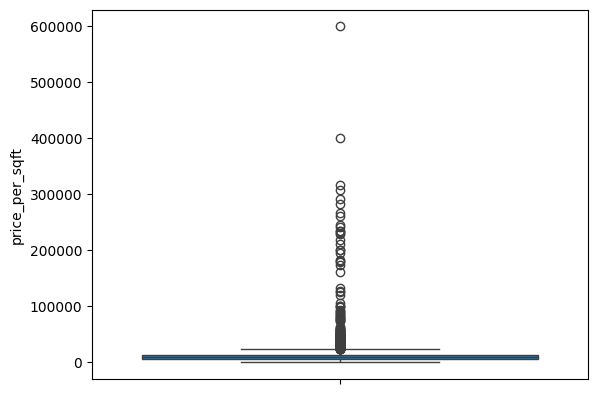

In [83]:
sns.boxplot(df['price_per_sqft'])

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

<Axes: xlabel='price_per_sqft', ylabel='Count'>

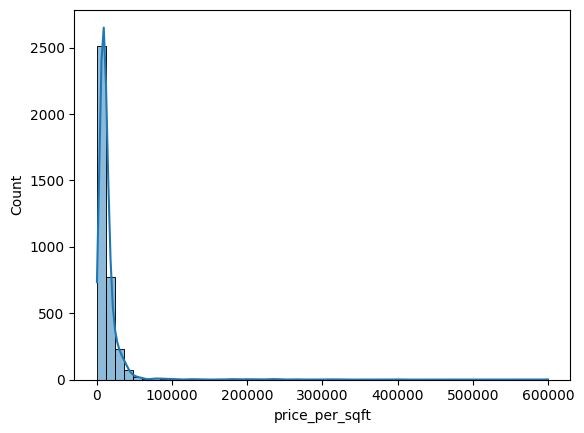

In [84]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

Potential Outliers
Right Skewed
17 missing values

6.bedRoom

<Axes: xlabel='bedRoom'>

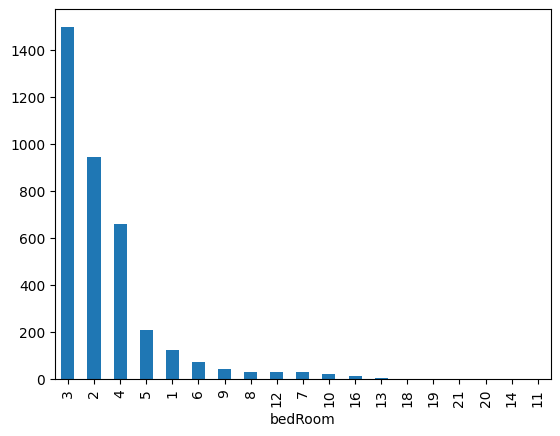

In [86]:
df['bedRoom'].value_counts().plot(kind='bar')

In [87]:
df['bedRoom'].describe()

count    3681.000000
mean        3.358870
std         1.897004
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

<Axes: >

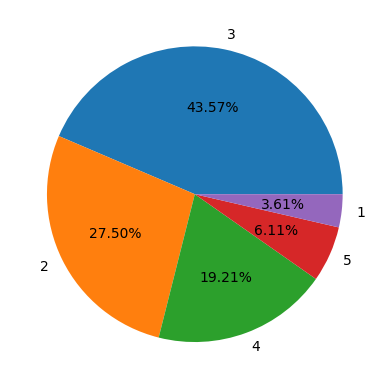

In [88]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

7. bathroom

In [89]:
df['bathroom'].describe()

count    3681.000000
mean        3.423526
std         1.947457
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bathroom, dtype: float64

In [90]:
df['bathroom'].value_counts()

bathroom
3     1077
2     1050
4      821
5      294
1      156
6      117
9       41
7       40
8       25
12      22
10       9
16       8
13       4
18       4
11       4
20       3
17       3
14       2
21       1
Name: count, dtype: int64

<Axes: xlabel='bathroom'>

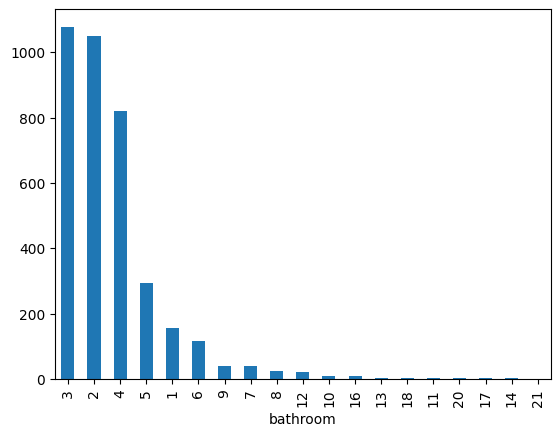

In [92]:
df['bathroom'].value_counts().plot(kind='bar')

<Axes: >

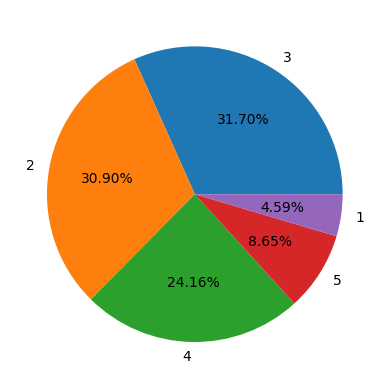

In [94]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

8. balcony

<Axes: xlabel='balcony'>

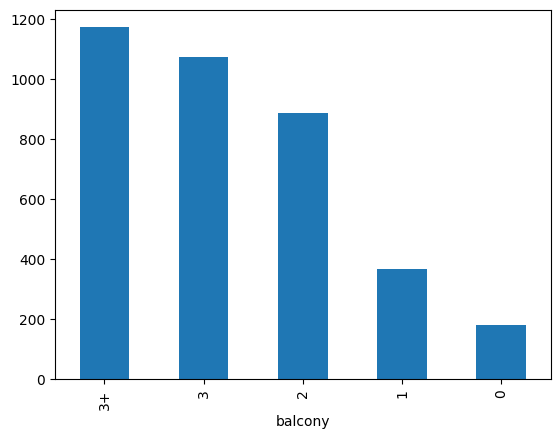

In [95]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: >

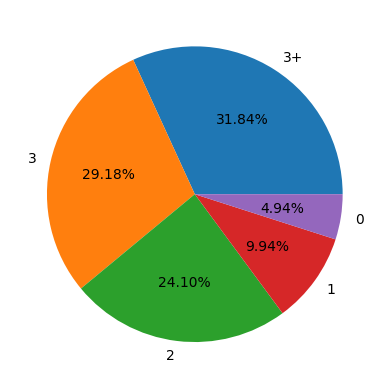

In [96]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

9.floornum

In [100]:
df.iloc[:,9:].head()

,balcony,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,1,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,3,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,2,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,3,5.0,NaN,1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


<Axes: xlabel='floorNum'>

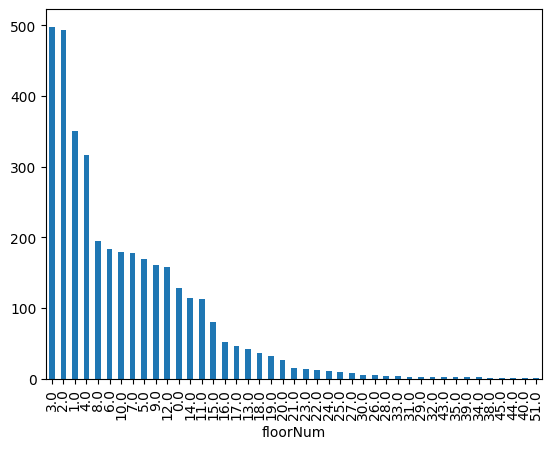

In [101]:
df['floorNum'].value_counts().plot(kind='bar')

<Axes: >

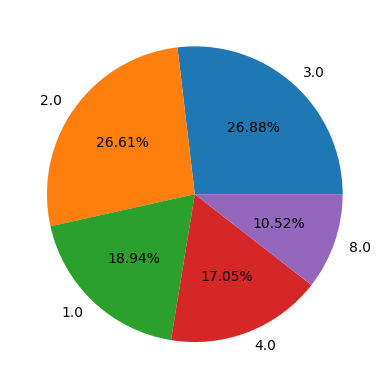

In [102]:
df['floorNum'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [103]:
df['floorNum'].describe()

count    3662.000000
mean        6.802294
std         6.011526
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

In [104]:
df['floorNum'].isnull().sum()

np.int64(19)

<Axes: ylabel='floorNum'>

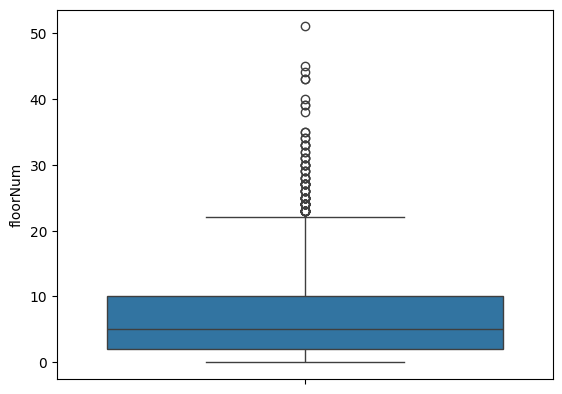

In [105]:
sns.boxplot(df['floorNum'])

The majority of the properties lie between the ground floor (0) and the 25th floor.
Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
There are a few properties located at higher floors, but their frequency is much lower.
The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

10. facing

In [106]:
df['facing'].isnull().sum()

np.int64(1047)

In [110]:
df['facing'].fillna('NA',inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8612\3692945726.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['facing'].fillna('NA',inplace=True)


0             West
1             West
2               NA
3               NA
4               NA
           ...    
3798    North-West
3799    North-East
3800         North
3801          East
3802          West
Name: facing, Length: 3681, dtype: str

In [111]:
df['facing'].value_counts()

facing
East          624
North-East    623
North         387
West          249
South         231
North-West    194
South-East    173
South-West    153
Name: count, dtype: int64

In [112]:
df['facing'].isnull().sum()

np.int64(1047)

11. age_category

In [113]:
df['age_category'].value_counts()

age_category
Relatively New        1788
New Property           617
Moderately Old         563
Undefined              309
Old Property           303
Under Construction     101
Name: count, dtype: int64

In [115]:
df['age_category'].isnull().sum()

np.int64(0)

<Axes: >

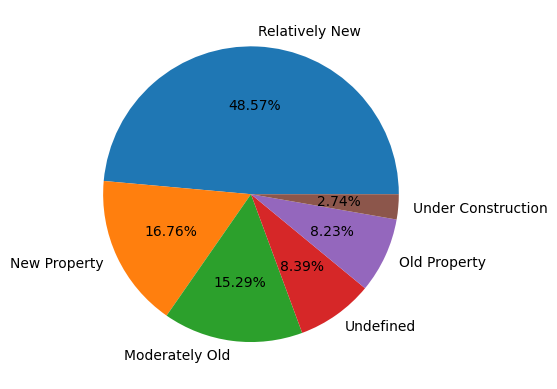

In [122]:
df['age_category'].value_counts().plot(kind='pie',autopct='%0.2f%%')

12. areas

In [123]:
df.iloc[:,10:].head()

,floorNum,facing,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,4.0,West,NaN,NaN,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,1.0,West,NaN,NaN,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,12.0,NaN,NaN,NaN,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,2.0,NaN,NaN,NaN,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,5.0,NaN,1345.0,NaN,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [124]:
df['super_built_up_area'].describe()

count     1876.000000
mean      1925.357436
std        763.985994
min         89.000000
25%       1479.750000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [125]:
df['super_built_up_area'].isnull().sum()

np.int64(1805)

<Axes: xlabel='super_built_up_area', ylabel='Count'>

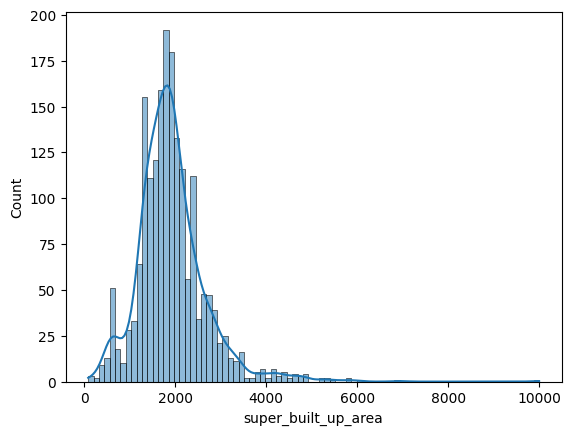

In [126]:
sns.histplot(df['super_built_up_area'],kde=True)

<Axes: ylabel='super_built_up_area'>

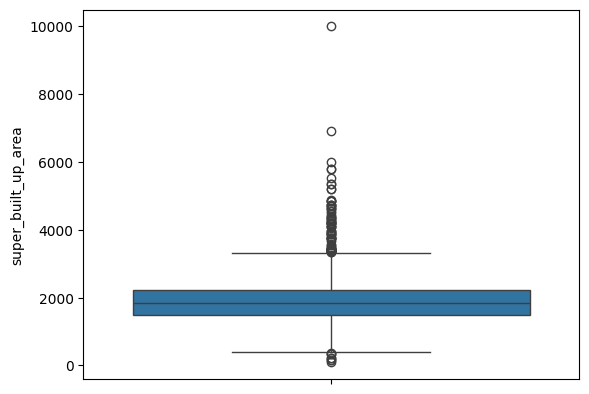

In [127]:
sns.boxplot(df['super_built_up_area'].dropna())

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
There are a few properties with a significantly larger area, leading to a right-skewed distribution.
The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [129]:
df['built_up_area'].isnull().sum()

np.int64(2533)

In [130]:
df['built_up_area'].describe()

count      1148.000000
mean       2429.883937
std       21741.736126
min          30.000000
25%        1120.000000
50%        1600.000000
75%        2060.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

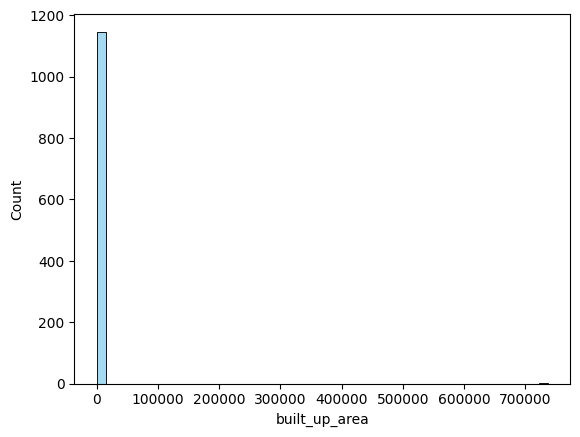

In [131]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

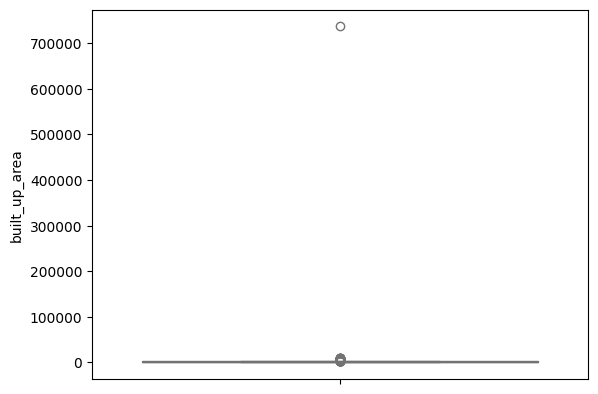

In [132]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.
The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [133]:
df['carpet_area'].describe()

count      1875.000000
mean       2526.323824
std       22781.691509
min          15.000000
25%         835.980000
50%        1300.000000
75%        1787.500000
max      607936.000000
Name: carpet_area, dtype: float64

In [135]:
df['carpet_area'].isnull().sum()

np.int64(1806)

<Axes: xlabel='carpet_area', ylabel='Count'>

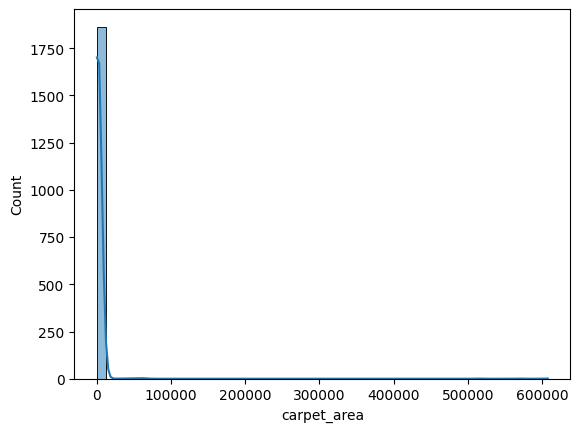

In [138]:
sns.histplot(df['carpet_area'].dropna(),kde=True,bins=50)

<Axes: ylabel='carpet_area'>

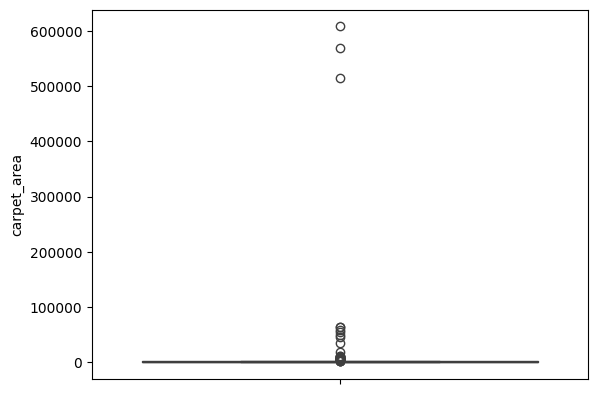

In [139]:
sns.boxplot(df['carpet_area'].dropna())

13. additional rooms

In [140]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.0


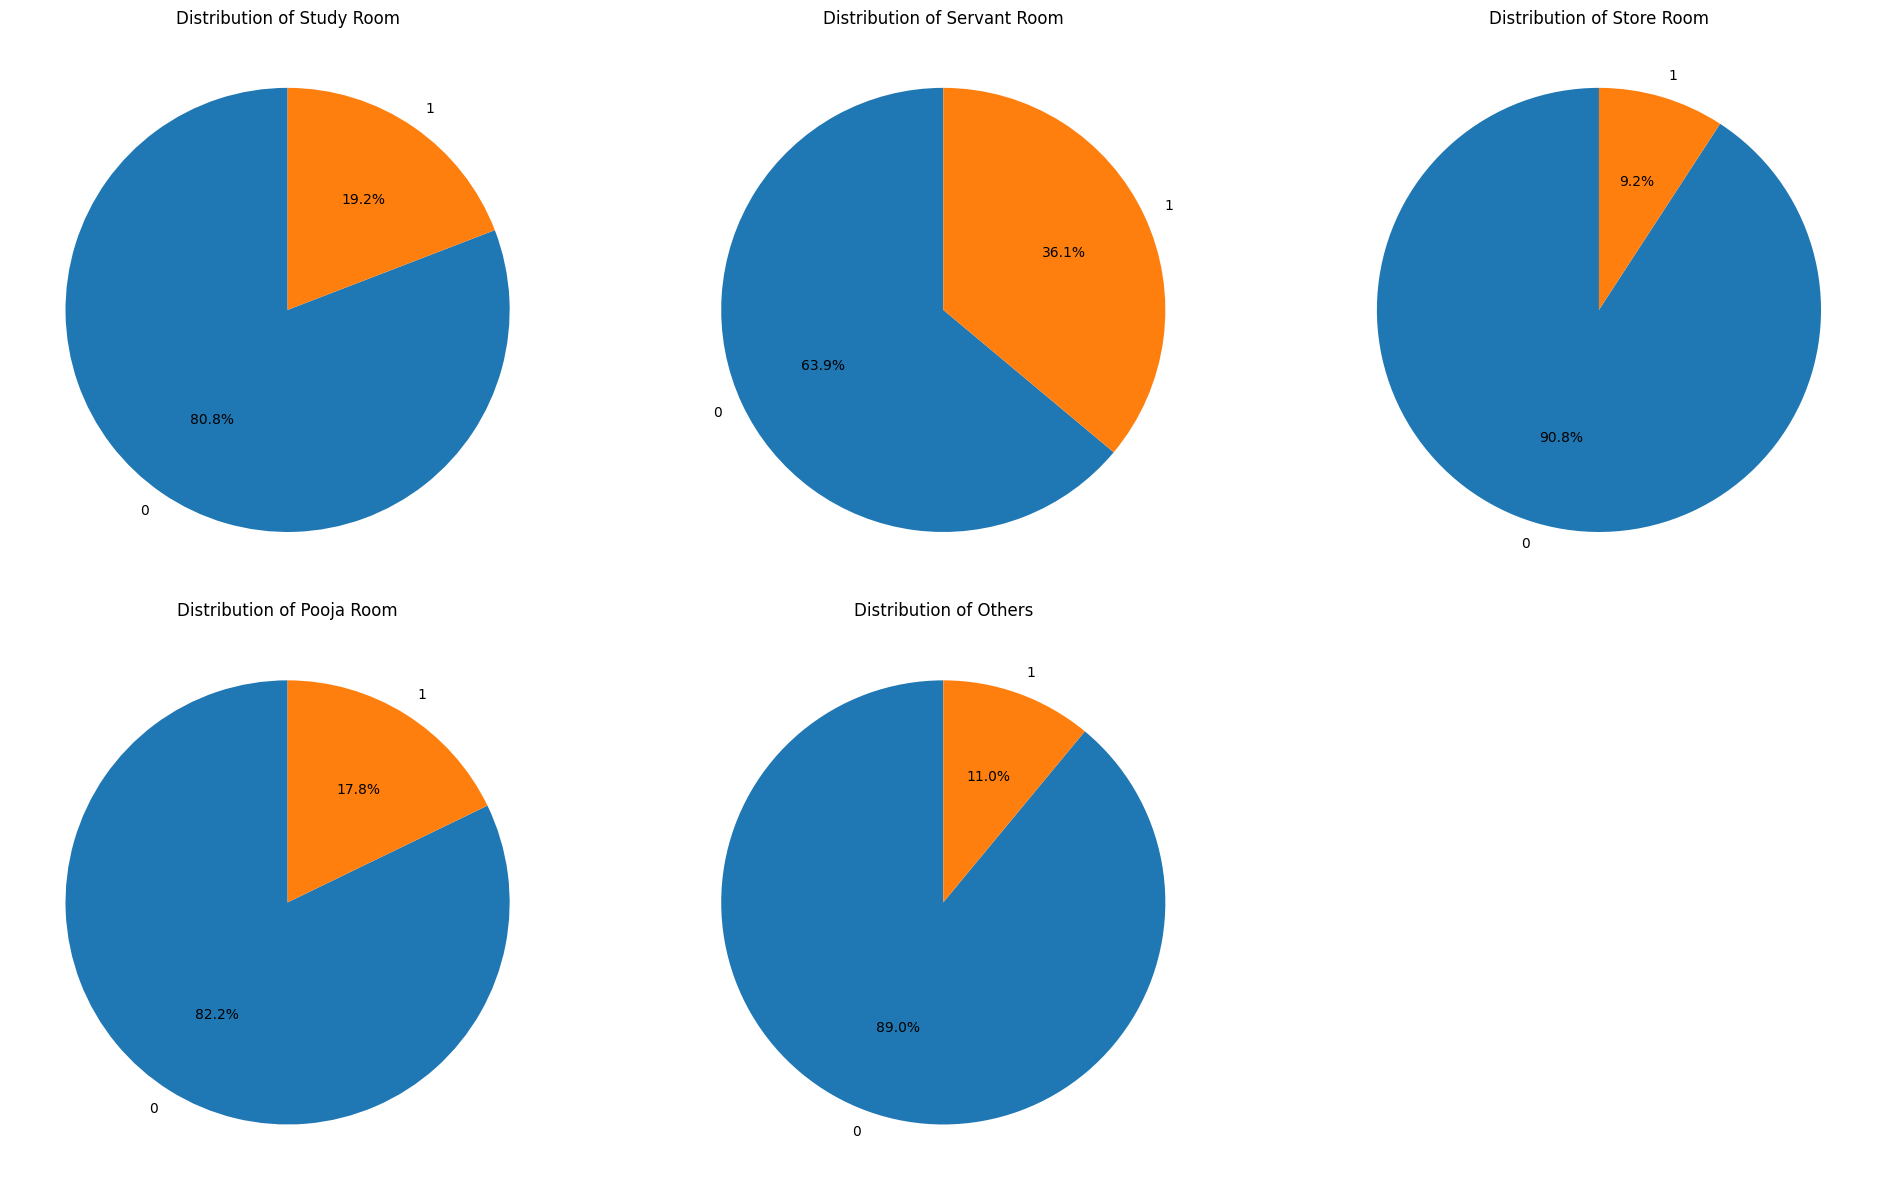

In [141]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

14. furnishing type

<Axes: >

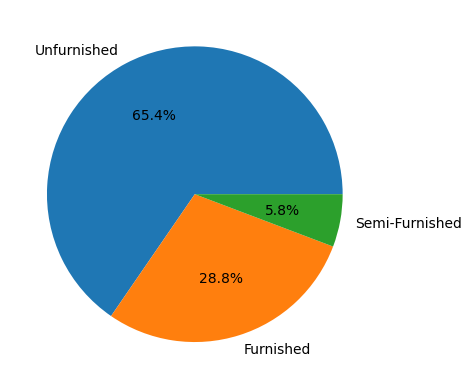

In [142]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%1.1f%%')

15. luxury_score

<Axes: xlabel='luxury_score', ylabel='Count'>

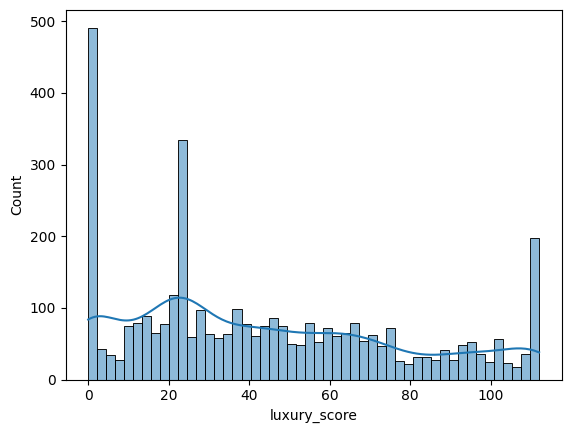

In [146]:
sns.histplot(df['luxury_score'],kde=True,bins=50)

<Axes: ylabel='luxury_score'>

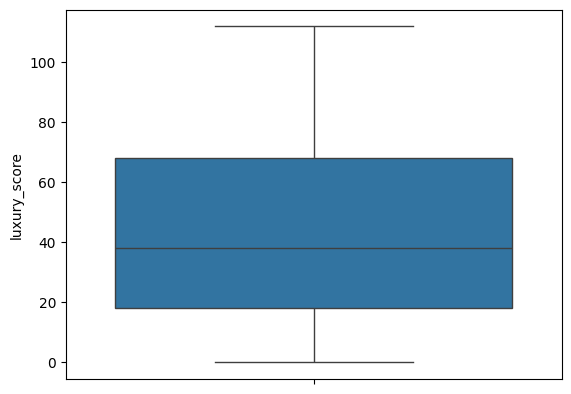

In [148]:
sns.boxplot(df['luxury_score'])

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

16. rating

In [149]:
df['combined_rating'].isnull().sum()

np.int64(337)

<Axes: xlabel='combined_rating', ylabel='Count'>

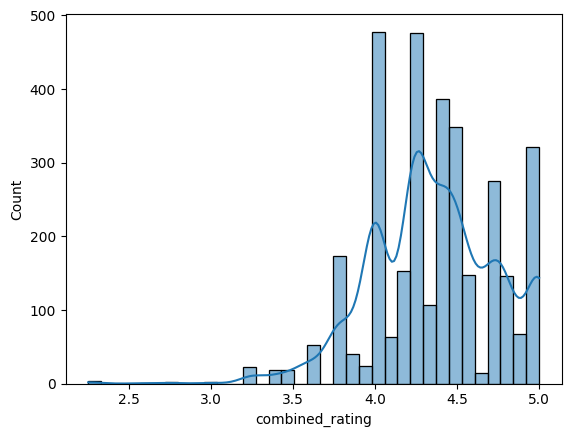

In [150]:
sns.histplot(df['combined_rating'], kde=True)

In [151]:
df['combined_rating'].describe()

count    3344.000000
mean        4.356959
std         0.386902
min         2.250000
25%         4.000000
50%         4.380000
75%         4.600000
max         5.000000
Name: combined_rating, dtype: float64

<Axes: ylabel='combined_rating'>

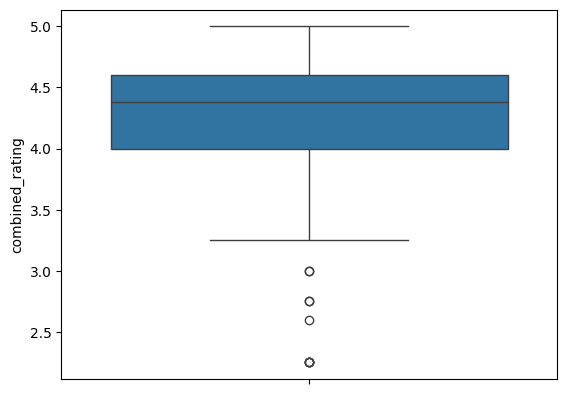

In [152]:
sns.boxplot(df['combined_rating'])

In [153]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,650.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,595.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,1200.0,1,0,0,0,0,Relatively New,Unfurnished,49,NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,NaN,1,0,0,0,0,Under Construction,Unfurnished,0,4.00
